In [1]:
# actor-critic的实现

import gym
import random
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import rc
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
def show_animation(imgs):
    rc("animation", html="jshtml")
    fig, ax = plt.subplots(1, 1, figsize=(5, 3))
    frames = []

    text = ax.text(10, 20, "", fontsize=12, color="black")

    for i, img in enumerate(imgs):
        frame = [ax.imshow(img, animated=True)]
        frame.append(ax.text(10, 20, f"Step: {i + 1}", animated=True))  # Step数表示
        frames.append(frame)

    ax.axis("off")

    ani = animation.ArtistAnimation(fig, frames, interval=100, blit=True)

    # 保存动画
    # ani.save("cartpole.mp4", writer="ffmpeg")
    ani.save("cartpole.gif", writer="pillow")

    plt.close(fig)
    return ani


def plot_loss(episode_list, return_list, filename):
    """绘制奖励图像"""
    f = plt.figure()
    plt.plot(episode_list, return_list)
    plt.xlabel("Episodes")
    plt.ylabel("Returns")
    plt.title("CartPole-v0")
    plt.show()
    f.savefig(filename, bbox_inches="tight")


class PolicyNet(nn.Module):
    """策略神经网络的结构"""

    def __init__(self, action_size):
        super().__init__()
        self.l1 = nn.Linear(4, 128)
        self.l2 = nn.Linear(128, action_size)

    def forward(self, x):  # x是S_t
        x = F.relu(self.l1(x))
        x = F.softmax(self.l2(x), dim=1)
        return x


class ValueNet(nn.Module):
    """价值函数神经网络V_ω"""

    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(4, 128)
        self.l2 = nn.Linear(128, 1)

    def forward(self, x):
        x = F.relu(self.l1(x))
        x = self.l2(x)
        return x


class Agent:
    def __init__(self):
        self.gamma = 0.98
        self.lr_pi = 0.0002
        self.lr_v = 0.005
        self.action_size = 2
        self.pi = PolicyNet(self.action_size)
        self.v = ValueNet()
        self.optimizer_pi = optim.Adam(self.pi.parameters(), lr=self.lr_pi)
        self.optimizer_v = optim.Adam(self.v.parameters(), lr=self.lr_v)

    def get_action(self, state):
        probs = self.pi(torch.tensor(state).unsqueeze(0)).squeeze(0)
        m = Categorical(probs)
        action = m.sample().item()
        return action, probs

    def collect_trajectory(self, env):
        """采样一条轨迹"""
        state = env.reset()
        states, next_states, actions, rewards, dones = [], [], [], [], []
        done = False

        while not done:
            action, _ = self.get_action(state)
            next_state, reward, done, _ = env.step(action)

            states.append(state)  # S_t
            next_states.append(next_state)  # S_(t+1)
            actions.append(action)  # A_t
            rewards.append(reward)  # R_t
            dones.append(done)  # done_t

            state = next_state

        # states: [S_0, S_1, S_2, ..., S_(T-1)]
        # next_states: [S_1, S_2, S_3, ..., S_T]
        # actions: [A_0, A_1, A_2, ..., A_(T-1)]
        # rewards: [R_0, R_1, R_2, ..., R_(T-1)]
        # dones: [False, False, False, ..., True]
        return states, next_states, actions, rewards, dones

    def update(self, trajectory):
        """整条轨迹的actor-critic更新"""
        states, next_states, actions, rewards, dones = trajectory

        states = torch.tensor(states)  # [S_0, S_1, S_2, ..., S_(T-1)]
        # [[A_0], [A_1], [A_2], ..., [A_(T-1)]]
        actions = torch.tensor(actions).view(-1, 1)
        # [[R_0], [R_1], [R_2], ..., [R_(T-1)]]
        rewards = torch.tensor(rewards).view(-1, 1)
        next_states = torch.tensor(next_states)  # [S_1, S_2 ..., S_T]
        dones = torch.tensor(dones, dtype=torch.float).view(-1, 1)

        v = self.v(states)  # [V(S_0), V(S_1), ..., V(S_(T-1))]
        # [R_0+γV(S_1), R_1+γV(S_2), ..., R_(T-1)]
        td_target = rewards + self.gamma * self.v(next_states) * (1 - dones)
        # 价值网络的损失，把td目标从计算图中剥离
        loss_v = F.mse_loss(v, td_target.detach())
        # 策略网络的损失，gather的用法要注意
        # self.pi(states): π_θ(a_t|s_t)
        # actions是真实标签
        # gather根据真实标签actions取出对应的概率
        # 例如self.pi(states)如下：
        # [[0.3, 0.7],
        #  [0.2, 0.8]]
        # actions如下：
        # [[1],
        #  [0]]
        # gather后的结果
        # [[0.7],
        #  [0.2]]
        action_probs = self.pi(states).gather(1, actions)
        # torch.log(action_probs): [logπ_θ(a_0|s_0),...,logπ_θ(a_(T-1)|s_(T-1))]
        # (td_target-v).detach():
        # [R_0+γV(S_1)-V(S_0),...,R_(T-1)+γV(S_T)-V(S_(T-1))]
        loss_pi = -torch.sum(torch.log(action_probs) * (td_target - v).detach())

        self.optimizer_pi.zero_grad()
        self.optimizer_v.zero_grad()
        loss_v.backward()
        loss_pi.backward()
        self.optimizer_pi.step()
        self.optimizer_v.step()

C:\MySoftware\Anaconda3\envs\python311\Lib\site-packages\gym\envs\registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
C:\MySoftware\Anaconda3\envs\python311\Lib\site-packages\gym\core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
C:\MySoftware\Anaconda3\envs\python311\Lib\site-packages\gym\wrappers\step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
C:\MySoftware\Anaconda3\envs\python311\Lib\site-packages\gym\utils\passive_env_checker.py:241: DeprecationWarning: `np.bool8` is a deprecated alias for 

回合：0, 总奖励：22.0
回合：100, 总奖励：17.0
回合：200, 总奖励：24.0
回合：300, 总奖励：52.0
回合：400, 总奖励：16.0
回合：500, 总奖励：32.0
回合：600, 总奖励：57.0
回合：700, 总奖励：52.0
回合：800, 总奖励：139.0
回合：900, 总奖励：153.0
回合：1000, 总奖励：135.0
回合：1100, 总奖励：200.0
回合：1200, 总奖励：200.0
回合：1300, 总奖励：200.0
回合：1400, 总奖励：163.0
回合：1500, 总奖励：200.0
回合：1600, 总奖励：200.0
回合：1700, 总奖励：200.0
回合：1800, 总奖励：200.0
回合：1900, 总奖励：200.0
回合：2000, 总奖励：200.0
回合：2100, 总奖励：200.0
回合：2200, 总奖励：200.0
回合：2300, 总奖励：200.0
回合：2400, 总奖励：200.0
回合：2500, 总奖励：200.0
回合：2600, 总奖励：200.0
回合：2700, 总奖励：200.0
回合：2800, 总奖励：200.0
回合：2900, 总奖励：200.0


C:\MySoftware\Anaconda3\envs\python311\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


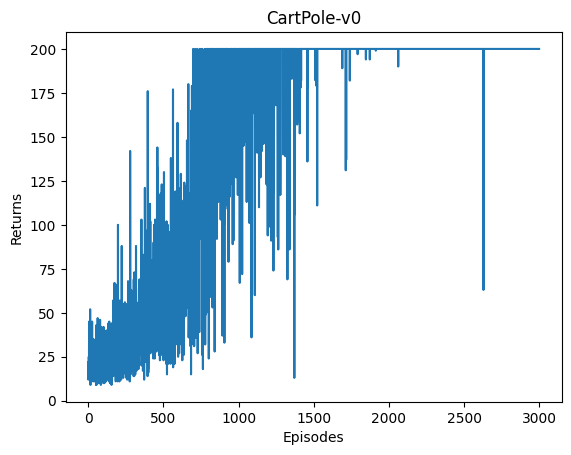

In [3]:
env = gym.make("CartPole-v0")
agent = Agent()
return_list = []
episode_list = []

for episode in range(3000):
    state = env.reset()  # S_0

    trajectory = agent.collect_trajectory(env)
    # 采样一条轨迹，更新一次策略网络和价值网络
    agent.update(trajectory)

    return_list.append(sum(trajectory[3]))
    episode_list.append(episode)
    if episode % 100 == 0:
        print(f"回合：{episode}, 总奖励：{sum(trajectory[3])}")

plot_loss(episode_list, return_list, "sample-one-trajectory-actor-critic-pg-loss.pdf")